In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
raw_data = pd.read_csv("../data/autos.csv")
print(raw_data.head())

   index          dateCrawled                            name  seller  \
0      0  2016-03-24 11:52:17                      Golf_3_1.6  privat   
1      1  2016-03-24 10:58:45            A5_Sportback_2.7_Tdi  privat   
2      2  2016-03-14 12:52:21  Jeep_Grand_Cherokee_"Overland"  privat   
3      3  2016-03-17 16:54:04              GOLF_4_1_4__3TÜRER  privat   
4      4  2016-03-31 17:25:20  Skoda_Fabia_1.4_TDI_PD_Classic  privat   

  offerType  price abtest vehicleType  yearOfRegistration    gearbox  ...  \
0   Angebot    480   test         NaN                1993    manuell  ...   
1   Angebot  18300   test       coupe                2011    manuell  ...   
2   Angebot   9800   test         suv                2004  automatik  ...   
3   Angebot   1500   test  kleinwagen                2001    manuell  ...   
4   Angebot   3600   test  kleinwagen                2008    manuell  ...   

   model kilometer  monthOfRegistration  fuelType       brand  \
0   golf    150000               

In [27]:
print(f"Shape of the dataset: {raw_data.shape}")
print(raw_data.info())

Shape of the dataset: (371528, 22)
<class 'pandas.DataFrame'>
RangeIndex: 371528 entries, 0 to 371527
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   index                371528 non-null  int64   
 1   dateCrawled          371528 non-null  str     
 2   name                 371528 non-null  str     
 3   seller               371528 non-null  str     
 4   offerType            371528 non-null  str     
 5   price                371528 non-null  int64   
 6   abtest               371528 non-null  str     
 7   vehicleType          333659 non-null  str     
 8   yearOfRegistration   371528 non-null  int64   
 9   gearbox              351319 non-null  str     
 10  powerPS              371528 non-null  int64   
 11  model                351044 non-null  str     
 12  kilometer            371528 non-null  int64   
 13  monthOfRegistration  371528 non-null  int64   
 14  fuelType             338142 

In [52]:
# count categorical cols, numerical cols and date cols
categorical_cols = raw_data.select_dtypes(include=["string"]).columns
numerical_cols = raw_data.select_dtypes(include=["int64", "float64"]).columns
print("Categorical columns:", len(categorical_cols))
print("Numerical columns:", len(numerical_cols))
missing_values = raw_data.isnull().sum()
print("Total missing values in the dataset:", missing_values.sum())



Categorical columns: 13
Numerical columns: 8
Total missing values in the dataset: 194786


In [54]:
numerical_cols_ = raw_data[["powerPS", "yearOfRegistration", "kilometer"]]
for col in numerical_cols_:
    print(f"Summary statistics for {col}:")
    print(raw_data[col].describe())
    print("\n")

Summary statistics for powerPS:
count    371528.000000
mean        115.549477
std         192.139578
min           0.000000
25%          70.000000
50%         105.000000
75%         150.000000
max       20000.000000
Name: powerPS, dtype: float64


Summary statistics for yearOfRegistration:
count    371528.000000
mean       2004.577997
std          92.866598
min        1000.000000
25%        1999.000000
50%        2003.000000
75%        2008.000000
max        9999.000000
Name: yearOfRegistration, dtype: float64


Summary statistics for kilometer:
count    371528.000000
mean     125618.688228
std       40112.337051
min        5000.000000
25%      125000.000000
50%      150000.000000
75%      150000.000000
max      150000.000000
Name: kilometer, dtype: float64




In [29]:
# exploring price col
print("Price column info:")
print(raw_data["price"].describe())

Price column info:
count    3.715280e+05
mean     1.729514e+04
std      3.587954e+06
min      0.000000e+00
25%      1.150000e+03
50%      2.950000e+03
75%      7.200000e+03
max      2.147484e+09
Name: price, dtype: float64


In [62]:
categorical_cols_ = raw_data[["gearbox", "notRepairedDamage"]]
for col in categorical_cols_:
    print(f"Categories values in {col}: {raw_data[col].value_counts()}")
    print("percentage of each category:")
    print((raw_data[col].value_counts() * 100 / len(raw_data)).round(2))

Categories values in gearbox: gearbox
manuell      274214
automatik     77105
Name: count, dtype: int64
percentage of each category:
gearbox
manuell      73.81
automatik    20.75
Name: count, dtype: float64
Categories values in notRepairedDamage: notRepairedDamage
nein    263182
ja       36286
Name: count, dtype: int64
percentage of each category:
notRepairedDamage
nein    70.84
ja       9.77
Name: count, dtype: float64


In [12]:
# defining the threshold for the price tiers
price_thresholds = [0, 5000, 15000, float("inf")]
price_labels = ["Budget(< $5,000)", "Mid-range($5,000 - $15,000)", "Luxury(> $15,000)"]
# creating a new column for price tiers
raw_data["price_tier"] = pd.cut(raw_data["price"], bins=price_thresholds, labels=price_labels)
print(raw_data["price_tier"].value_counts())
print((raw_data["price_tier"].value_counts()/len(raw_data["price_tier"]) * 100).round(2), "%")
# print(raw_data_no_outliers[["price", "price_tier"]].head())

price_tier
Budget(< $5,000)               233707
Mid-range($5,000 - $15,000)     95016
Luxury(> $15,000)               32027
Name: count, dtype: int64
price_tier
Budget(< $5,000)               62.90
Mid-range($5,000 - $15,000)    25.57
Luxury(> $15,000)               8.62
Name: count, dtype: float64 %


In [33]:
# checking for missing values
missing_values = raw_data.isnull().sum()

print("Total missing values in the dataset:", missing_values.sum())
print("Missing values in each column:")
print(f"{missing_values[missing_values > 0]}")
print(f"{(missing_values[missing_values > 0] * 100 / len(raw_data)).round(2)}")

Total missing values in the dataset: 194786
Missing values in each column:
vehicleType          37869
gearbox              20209
model                20484
fuelType             33386
notRepairedDamage    72060
price_tier           10778
dtype: int64
vehicleType          10.19
gearbox               5.44
model                 5.51
fuelType              8.99
notRepairedDamage    19.40
price_tier            2.90
dtype: float64


In [ ]:
# checking for full-duplicates rows
duplicate_rows = raw_data[raw_data.duplicated()]
print("Number of duplicate rows:", duplicate_rows.shape[0])


Number of duplicate rows: 0


In [102]:
print(raw_data["yearOfRegistration"].describe())
print(raw_data["yearOfRegistration"].skew())

count    371528.000000
mean       2004.577997
std          92.866598
min        1000.000000
25%        1999.000000
50%        2003.000000
75%        2008.000000
max        9999.000000
Name: yearOfRegistration, dtype: float64
72.13364168417988


In [68]:
print(raw_data["dateCrawled"].describe())

count                  371528
unique                 280500
top       2016-03-24 14:49:47
freq                        7
Name: dateCrawled, dtype: object


In [80]:
print(raw_data["powerPS"].describe())

count    371528.000000
mean        115.549477
std         192.139578
min           0.000000
25%          70.000000
50%         105.000000
75%         150.000000
max       20000.000000
Name: powerPS, dtype: float64


In [90]:
# Data Validity Checks
print("Check for invalid powerPS values (<= 0) or (>= 5000):")
print(raw_data[raw_data['powerPS']<=0]["powerPS"].count())
print(raw_data[raw_data['powerPS']>=5000]["powerPS"].count())
print(f"Total invalid powerPS values: {(raw_data[raw_data['powerPS']<=0]['powerPS'].count() + raw_data[raw_data['powerPS']>=5000]['powerPS'].count())}")
print(f"percentage of invalid powerPS values: {((raw_data[raw_data['powerPS']<=0]['powerPS'].count() + raw_data[raw_data['powerPS']>=5000]['powerPS'].count()) * 100 / len(raw_data)).round(2)}% ")

print("Check for invalid kilometer values (< 0) or (> 300000):")
print(raw_data[raw_data['kilometer']<0]["kilometer"].count())
print(raw_data[raw_data['kilometer']>300000]["kilometer"].count())
print(f"Total invalid kilometer values: {(raw_data[raw_data['kilometer']<0]['kilometer'].count() + raw_data[raw_data['kilometer']>300000]['kilometer'].count())}")
print(f"percentage of invalid kilometer values: {((raw_data[raw_data['kilometer']<0]['kilometer'].count() + raw_data[raw_data['kilometer']>300000]['kilometer'].count()) * 100 / len(raw_data)).round(2)}% ")

print("Check for invalid yearOfRegistration values (< 1900):")
print(raw_data[raw_data['yearOfRegistration']<1900]["yearOfRegistration"].count())
print(f"Total invalid yearOfRegistration values: {raw_data[raw_data['yearOfRegistration']<1900]['yearOfRegistration'].count()}")
print("Check for invalid yearOfRegistration values (> 2023):")
print(raw_data[raw_data['yearOfRegistration']>2023]["yearOfRegistration"].count())
print(f"Total invalid yearOfRegistration values: {raw_data[raw_data['yearOfRegistration']>2023]['yearOfRegistration'].count()+raw_data[raw_data['yearOfRegistration']<1900]['yearOfRegistration'].count()}")
print(f"percentage of invalid yearOfRegistration values: {((raw_data[raw_data['yearOfRegistration']>2023]['yearOfRegistration'].count()+raw_data[raw_data['yearOfRegistration']<1900]['yearOfRegistration'].count()) * 100 / len(raw_data)).round(2)}% ")


Check for invalid powerPS values (<= 0) or (>= 5000):
40820
87
Total invalid powerPS values: 40907
percentage of invalid powerPS values: 11.01% 
Check for invalid kilometer values (< 0) or (> 300000):
0
0
Total invalid kilometer values: 0
percentage of invalid kilometer values: 0.0% 
Check for invalid yearOfRegistration values (< 1900):
68
Total invalid yearOfRegistration values: 68
Check for invalid yearOfRegistration values (> 2023):
114
Total invalid yearOfRegistration values: 182
percentage of invalid yearOfRegistration values: 0.05% 


In [94]:
print("Check for invalid price values (< 0):")
print(raw_data[raw_data['price']<0]["price"].count())
print(f"Total invalid price values: {raw_data[raw_data['price']<0]['price'].count()}")
print(f"percentage of invalid price values: {((raw_data[raw_data['price']<0]['price'].count()) * 100 / len(raw_data)).round(2)}% ")


Check for invalid price values (< 0):
0
Total invalid price values: 0
percentage of invalid price values: 0.0% 


In [96]:
# removing outliers from price col using IQR method
print(raw_data["price"].describe())
Q1 = raw_data["price"].quantile(0.25)
Q3 = raw_data["price"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
raw_data_outliers = raw_data[(raw_data["price"] < lower_bound) | (raw_data["price"] > upper_bound)]
raw_data_no_outliers = raw_data[(raw_data["price"] >= lower_bound) & (raw_data["price"] <= upper_bound)]
print("Number of outliers in price column:", raw_data_outliers.shape[0])
print("Percentage of outliers in price column:", (raw_data_outliers.shape[0] / len(raw_data)) * 100)


count    3.715280e+05
mean     1.729514e+04
std      3.587954e+06
min      0.000000e+00
25%      1.150000e+03
50%      2.950000e+03
75%      7.200000e+03
max      2.147484e+09
Name: price, dtype: float64
Number of outliers in price column: 28108
Percentage of outliers in price column: 7.565513231842553


In [ ]:
# Outliers in kilometer col using IQR method
print(raw_data["kilometer"].describe())
Q1_km = raw_data["kilometer"].quantile(0.25)
Q3_km = raw_data["kilometer"].quantile(0.75)
IQR_km = Q3_km - Q1_km
lower_bound_km = Q1_km - 1.5 * IQR_km
upper_bound_km = Q3_km + 1.5 * IQR_km
raw_data_km_outliers = raw_data[(raw_data["kilometer"] < lower_bound_km) | (raw_data["kilometer"] > upper_bound_km)]
raw_data_km_no_outliers = raw_data[(raw_data["kilometer"] >= lower_bound_km) & (raw_data["kilometer"] <= upper_bound_km)]
print("Number of outliers in kilometer column:", raw_data_km_outliers.shape[0])
print("Percentage of outliers in kilometer column:", (raw_data_km_outliers.shape[0] / len(raw_data)) * 100) 

count    371528.000000
mean     125618.688228
std       40112.337051
min        5000.000000
25%      125000.000000
50%      150000.000000
75%      150000.000000
max      150000.000000
Name: kilometer, dtype: float64
Skewness of kilometer column: -1.5515772692054193
Number of outliers in kilometer column: 64221
Percentage of outliers in kilometer column: 17.28564199737301


In [100]:
# Skewness
print("Skewness of price column:", raw_data["price"].skew())
print("Skewness of kilometer column:", raw_data["kilometer"].skew())
print("Skewness of power column:", raw_data["powerPS"].skew())
print("Skewness of registration year column:", raw_data["yearOfRegistration"].skew())

Skewness of price column: 578.059083655185
Skewness of kilometer column: -1.5515772692054193
Skewness of power column: 58.19990872520754
Skewness of registration year column: 72.13364168417988


In [ ]:
# Checking Consistency - Schema & Data Types
print("Data Types of Each Column:")
print(raw_data.dtypes)


Data Types of Each Column:
index                     int64
dateCrawled                 str
name                        str
seller                      str
offerType                   str
price                     int64
abtest                      str
vehicleType                 str
yearOfRegistration        int64
gearbox                     str
powerPS                   int64
model                       str
kilometer                 int64
monthOfRegistration       int64
fuelType                    str
brand                       str
notRepairedDamage           str
dateCreated                 str
nrOfPictures              int64
postalCode                int64
lastSeen                    str
price_tier             category
dtype: object


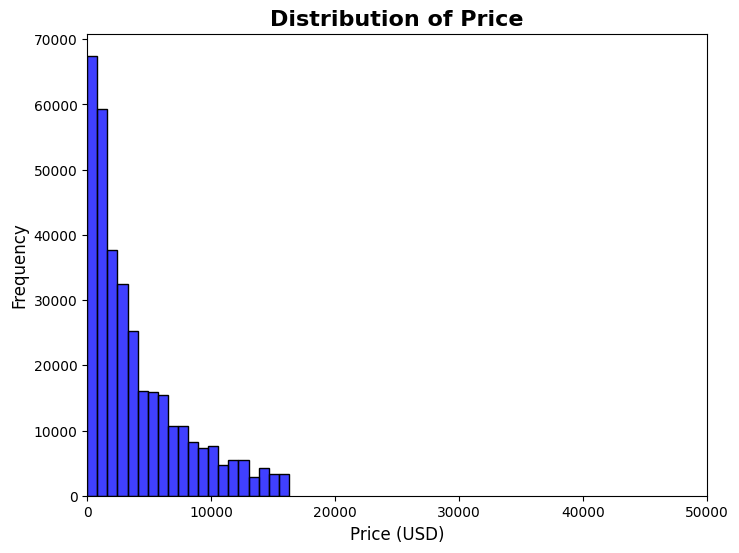

In [9]:
# visualizing the distribution of price tiers
plt.figure(figsize=(8, 6))
sns.histplot(raw_data_no_outliers["price"], bins=20, color="blue")
plt.title("Distribution of Price", fontsize=16, fontweight='bold')
plt.xlabel("Price (USD)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xlim(0, 50000)
plt.savefig("../reports/price_distribution.png")
plt.show()

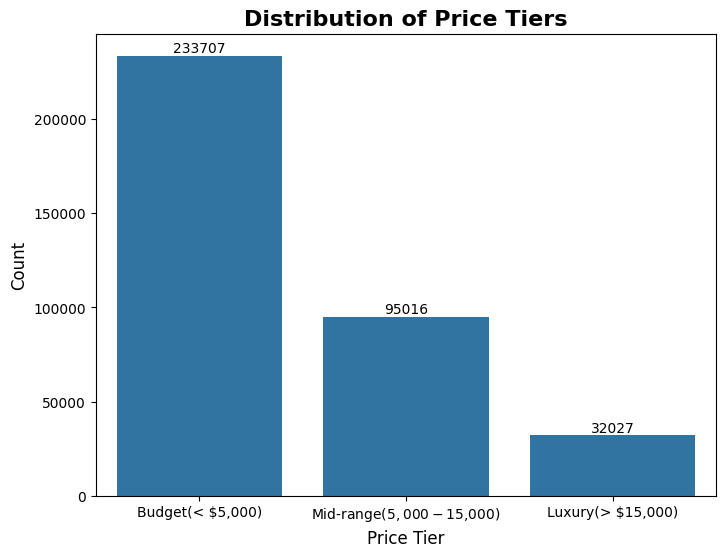

In [13]:
plt.figure(figsize=(8, 6))
sns.countplot(x="price_tier", data=raw_data)
plt.title("Distribution of Price Tiers", fontsize=16, fontweight='bold')
plt.xlabel("Price Tier", fontsize=12)
plt.ylabel("Count", fontsize=12)
for index, value in enumerate(raw_data["price_tier"].value_counts()):
    plt.text(index, value, str(value), ha='center', va='bottom')
plt.savefig("../reports/price_tier_distribution.png")
plt.show()